# Linear Regression From Scratch

In this notebook, you will learn how to implement **Linear Regression** from scratch using only NumPy. 

## Learning Objectives
- Understand the mathematical foundation of linear regression
- Implement the prediction function: $y = wx + b$
- Compute Mean Squared Error (MSE) loss
- Calculate gradients using calculus
- Implement gradient descent optimization
- Train a model to predict student grades based on study time
- Save and load trained model weights
- Make predictions on new data

## Dataset
We'll use a dataset of student study times (in minutes) and their corresponding grades (0-100).

## Table of Contents
- [1 - Import Packages](#1)
- [2 - Load and Visualize Dataset](#2)
- [3 - Linear Regression Theory](#3)
  - [3.1 - The Prediction Formula](#3-1)
  - [3.2 - Mean Squared Error (MSE)](#3-2)
  - [3.3 - Computing Gradients](#3-3)
  - [3.4 - Gradient Descent](#3-4)
- [4 - Implementation From Scratch](#4)
  - [4.1 - Prediction Function](#4-1)
  - [4.2 - MSE Loss Function](#4-2)
  - [4.3 - Compute Gradients](#4-3)
  - [4.4 - Gradient Descent](#4-4)
  - [4.5 - Training Function](#4-5)
- [5 - Train the Model](#5)
- [6 - Save Model Weights](#6)
- [7 - Load Model Weights](#7)
- [8 - Test on New Data](#8)
- [9 - Visualize Results](#9)
- [10 - Conclusion](#10)

<a name='1'></a>
## 1 - Import Packages

Let's start by importing the necessary packages:
- **numpy**: For numerical computations
- **matplotlib**: For visualizations
- **pandas**: For loading and manipulating the dataset
- **pickle**: For saving and loading model weights

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import os

%matplotlib inline

<a name='2'></a>
## 2 - Load and Visualize Dataset

Let's load our dataset containing student study times and their corresponding grades.

In [5]:
# Load the dataset
data = pd.read_csv('dataset_study.csv',index_col=0)

In [6]:
# Display first few rows
print("First 5 samples of the dataset:")
data.head()

First 5 samples of the dataset:


,study_hours,grade
student_id,,
1,9.15,91.91
2,9.37,86.81
3,2.86,53.39
4,8.30,85.52
5,6.42,77.98


In [7]:
# Display dataset statistics
print("\nDataset Statistics:")
print(data.describe())

print(f"\nTotal number of samples: {len(data)}")


Dataset Statistics:
       study_hours        grade
count  5000.000000  5000.000000
mean      5.031654    64.969712
std       2.910579    17.657329
min       0.000000    15.520000
25%       2.520000    51.717500
50%       5.050000    64.975000
75%       7.582500    78.710000
max      10.000000   100.000000

Total number of samples: 5000


X shape: (5000,)
y shape: (5000,)


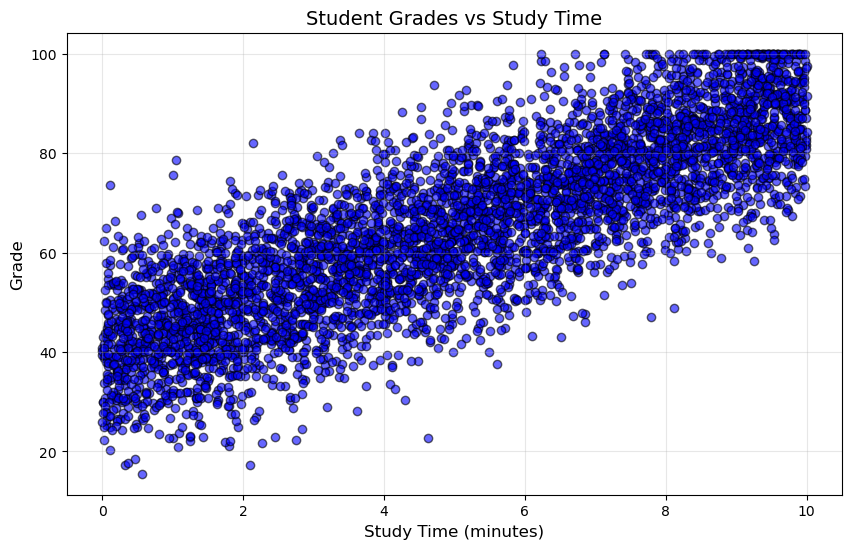


As you can see, there's a positive correlation between study time and grades!


In [8]:
# Extract features (X) and labels (y)
X = data['study_hours'].values
y = data['grade'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, color='blue', edgecolors='k')
plt.xlabel('Study Time (minutes)', fontsize=12)
plt.ylabel('Grade', fontsize=12)
plt.title('Student Grades vs Study Time', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("\nAs you can see, there's a positive correlation between study time and grades!")

<a name='3'></a>
## 3 - Linear Regression Theory

Before implementing, let's understand the mathematics behind linear regression.

<a name='3-1'></a>
### 3.1 - The Prediction Formula

In linear regression, we want to find a linear relationship between the input feature $x$ (study time) and the output $y$ (grade).

The prediction formula is:

$$\hat{y} = wx + b$$

Where:
- $\hat{y}$ is the predicted value
- $x$ is the input feature (study time)
- $w$ is the weight (slope of the line)
- $b$ is the bias (y-intercept)

For multiple samples, we can vectorize this as:

$$\hat{Y} = wX + b$$

Where $X$ and $\hat{Y}$ are vectors of all input features and predictions.

<a name='3-2'></a>
### 3.2 - Mean Squared Error (MSE)

To train our model, we need to measure how far our predictions are from the actual values. We use **Mean Squared Error (MSE)** as our loss function:

$$\text{MSE} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$

Where:
- $m$ is the number of training examples
- $\hat{y}^{(i)}$ is the predicted value for example $i$
- $y^{(i)}$ is the actual value for example $i$

The MSE measures the average squared difference between predictions and actual values. Our goal is to **minimize this error** by finding the best values for $w$ and $b$.

<a name='3-3'></a>
### 3.3 - Computing Gradients

To minimize the MSE, we need to know how the loss changes when we adjust $w$ and $b$. This is done using **gradients** (partial derivatives).

The gradient of MSE with respect to $w$:

$$\frac{\partial \text{MSE}}{\partial w} = \frac{2}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) \cdot x^{(i)}$$

In vectorized form:

$$\frac{\partial \text{MSE}}{\partial w} = \frac{2}{m} X^T (\hat{Y} - Y)$$

The gradient of MSE with respect to $b$:

$$\frac{\partial \text{MSE}}{\partial b} = \frac{2}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

In vectorized form:

$$\frac{\partial \text{MSE}}{\partial b} = \frac{2}{m} \sum (\hat{Y} - Y)$$

These gradients tell us the direction and magnitude to adjust $w$ and $b$ to reduce the error.

<a name='3-4'></a>
### 3.4 - Gradient Descent

**Gradient Descent** is an optimization algorithm that iteratively adjusts the parameters to minimize the loss function.

The update rules are:

$$w := w - \alpha \frac{\partial \text{MSE}}{\partial w}$$

$$b := b - \alpha \frac{\partial \text{MSE}}{\partial b}$$

Where:
- $\alpha$ is the **learning rate** (controls the step size)
- The gradients tell us which direction to move

We repeat this process for many iterations until the model converges (the loss stops decreasing significantly).

<a name='4'></a>
## 4 - Implementation From Scratch

Now let's implement each component of linear regression from scratch!

<a name='4-1'></a>
### 4.1 - Prediction Function

First, let's implement the prediction function: $\hat{y} = wx + b$

In [63]:
def predict(X, w, b):
    """
    Compute predictions using linear regression formula.
    
    Arguments:
    X -- input features, numpy array of shape (m,) where m is number of examples
    w -- weight parameter (slope)
    b -- bias parameter (intercept)
    
    Returns:
    y_pred -- predictions, numpy array of shape (m,)
    """
    X = (X - np.mean(X)) / np.std(X)
    y_pred = w * X + b
    return y_pred

In [64]:
# Test the prediction function
test_X = np.array([100, 200, 300])
test_w = 0.03
test_b = 40

test_predictions = predict(test_X, test_w, test_b)
print(f"Test inputs: {test_X}")
print(f"Test predictions: {test_predictions}")
print(f"\nWith w={test_w} and b={test_b}:")
print(f"  - {test_X[0]} minutes of study → predicted grade: {test_predictions[0]}")
print(f"  - {test_X[1]} minutes of study → predicted grade: {test_predictions[1]}")
print(f"  - {test_X[2]} minutes of study → predicted grade: {test_predictions[2]}")

Test inputs: [100 200 300]
Test predictions: [39.96325765 40.         40.03674235]

With w=0.03 and b=40:
  - 100 minutes of study → predicted grade: 39.96325765385825
  - 200 minutes of study → predicted grade: 40.0
  - 300 minutes of study → predicted grade: 40.03674234614175


<a name='4-2'></a>
### 4.2 - MSE Loss Function

Now let's implement the Mean Squared Error loss function.

In [65]:
def compute_mse(y_true, y_pred):
    """
    Compute Mean Squared Error between true and predicted values.
    
    Arguments:
    y_true -- actual values, numpy array of shape (m,)
    y_pred -- predicted values, numpy array of shape (m,)
    
    Returns:
    mse -- mean squared error (scalar)
    """
    m = len(y_true)
    mse = (1/m) * np.sum((y_pred - y_true)**2)
    return mse

In [66]:
# Test the MSE function
test_y_true = np.array([50, 60, 70])
test_y_pred = np.array([48, 62, 68])

test_mse = compute_mse(test_y_true, test_y_pred)
print(f"True values: {test_y_true}")
print(f"Predicted values: {test_y_pred}")
print(f"Mean Squared Error: {test_mse:.2f}")
print(f"\nLower MSE means better predictions!")

True values: [50 60 70]
Predicted values: [48 62 68]
Mean Squared Error: 4.00

Lower MSE means better predictions!


<a name='4-3'></a>
### 4.3 - Compute Gradients

Implement the gradient computation for both $w$ and $b$.

In [67]:
def compute_gradients(X, y_true, y_pred):
    """
    Compute gradients of MSE with respect to w and b.
    
    Arguments:
    X -- input features, numpy array of shape (m,)
    y_true -- actual values, numpy array of shape (m,)
    y_pred -- predicted values, numpy array of shape (m,)
    
    Returns:
    dw -- gradient with respect to w (scalar)
    db -- gradient with respect to b (scalar)
    """
    m = len(y_true)
    
    # Compute error
    error = y_pred - y_true
    
    # Compute gradients
    dw = (2/m) * np.sum(error * X)
    db = (2/m) * np.sum(error)
    
    return dw, db

In [68]:
# Test the gradient function
test_X = np.array([100, 200, 300])
test_y_true = np.array([50, 60, 70])
test_y_pred = np.array([48, 62, 68])

test_dw, test_db = compute_gradients(test_X, test_y_true, test_y_pred)
print(f"Gradient with respect to w (dw): {test_dw:.4f}")
print(f"Gradient with respect to b (db): {test_db:.4f}")
print(f"\nThese gradients tell us how to adjust w and b to reduce the error.")

Gradient with respect to w (dw): -266.6667
Gradient with respect to b (db): -1.3333

These gradients tell us how to adjust w and b to reduce the error.


<a name='4-4'></a>
### 4.4 - Gradient Descent

Implement one step of gradient descent to update the parameters.

In [69]:
def gradient_descent_step(w, b, dw, db, learning_rate):
    """
    Perform one step of gradient descent.
    
    Arguments:
    w -- current weight
    b -- current bias
    dw -- gradient with respect to w
    db -- gradient with respect to b
    learning_rate -- step size for updates
    
    Returns:
    w_new -- updated weight
    b_new -- updated bias
    """
    w_new = w - learning_rate * dw
    b_new = b - learning_rate * db
    
    return w_new, b_new

In [70]:
# Test gradient descent step
test_w = 0.03
test_b = 40
test_dw = 0.5
test_db = 2.0
test_lr = 0.01

new_w, new_b = gradient_descent_step(test_w, test_b, test_dw, test_db, test_lr)
print(f"Before update: w = {test_w}, b = {test_b}")
print(f"Gradients: dw = {test_dw}, db = {test_db}")
print(f"Learning rate: {test_lr}")
print(f"After update: w = {new_w}, b = {new_b}")

Before update: w = 0.03, b = 40
Gradients: dw = 0.5, db = 2.0
Learning rate: 0.01
After update: w = 0.024999999999999998, b = 39.98


<a name='4-5'></a>
### 4.5 - Training Function

Now let's combine everything into a complete training function.

In [71]:
def train_linear_regression(X, y, learning_rate=0.0001, num_iterations=1000, print_cost=True):
    """
    Train a linear regression model using gradient descent.
    
    Arguments:
    X -- input features, numpy array of shape (m,)
    y -- target values, numpy array of shape (m,)
    learning_rate -- learning rate for gradient descent
    num_iterations -- number of training iterations
    print_cost -- if True, print the cost every 100 iterations
    
    Returns:
    w -- trained weight
    b -- trained bias
    costs -- list of costs during training (for plotting)
    """
    # Initialize parameters
    w = 0.0
    b = 0.0
    
    costs = []
    
    for i in range(num_iterations):
        # Forward pass: compute predictions
        y_pred = predict(X, w, b)
        
        # Compute loss
        cost = compute_mse(y, y_pred)
        
        # Compute gradients
        dw, db = compute_gradients(X, y, y_pred)
        
        # Update parameters
        w, b = gradient_descent_step(w, b, dw, db, learning_rate)
        
        # Record cost
        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Iteration {i}: MSE = {cost:.2f}")
    
    # Print final results
    if print_cost:
        print(f"\n{'='*50}")
        print(f"Training Complete!")
        print(f"Final MSE: {cost:.2f}")
        print(f"Learned parameters: w = {w:.6f}, b = {b:.6f}")
        print(f"{'='*50}")
    
    return w, b, costs

<a name='5'></a>
## 5 - Train the Model

Let's train our linear regression model on the study time and grades dataset!

In [73]:
# Train the model
print("Starting training...\n")

w_trained, b_trained, training_costs = train_linear_regression(
    X, y,
    learning_rate=0.001,
    num_iterations=2000,
    print_cost=True
)

Starting training...

Iteration 0: MSE = 8231.35
Iteration 100: MSE = 14123.20
Iteration 200: MSE = 9495.63
Iteration 300: MSE = 6394.93
Iteration 400: MSE = 4317.29
Iteration 500: MSE = 2925.17
Iteration 600: MSE = 1992.38
Iteration 700: MSE = 1367.36
Iteration 800: MSE = 948.56
Iteration 900: MSE = 667.95
Iteration 1000: MSE = 479.92
Iteration 1100: MSE = 353.93
Iteration 1200: MSE = 269.52
Iteration 1300: MSE = 212.95
Iteration 1400: MSE = 175.05
Iteration 1500: MSE = 149.65
Iteration 1600: MSE = 132.64
Iteration 1700: MSE = 121.24
Iteration 1800: MSE = 113.60
Iteration 1900: MSE = 108.48

Training Complete!
Final MSE: 105.07
Learned parameters: w = 11.503446, b = 88.053837


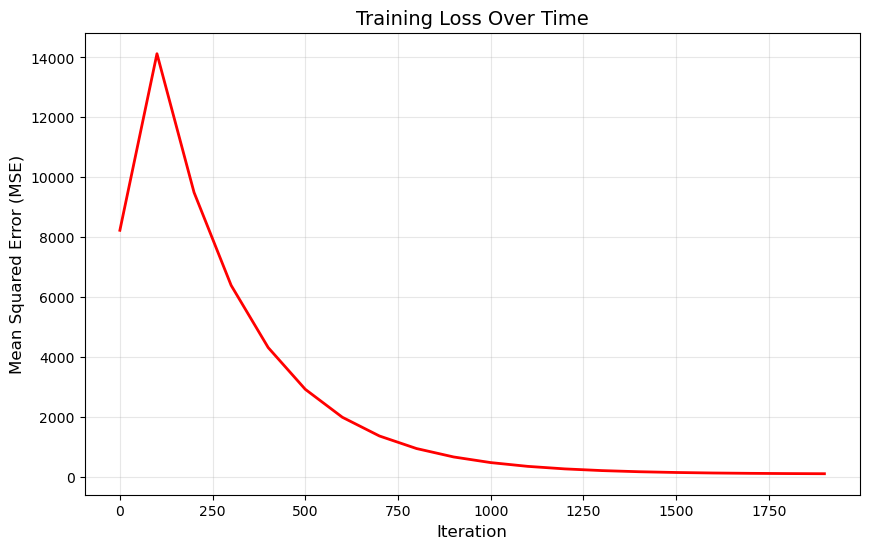

The decreasing loss shows that our model is learning!


In [74]:
# Plot the training curve
plt.figure(figsize=(10, 6))
plt.plot(range(0, len(training_costs)*100, 100), training_costs, linewidth=2, color='red')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Training Loss Over Time', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("The decreasing loss shows that our model is learning!")

<a name='6'></a>
## 6 - Save Model Weights

Now that we've trained our model, let's save the weights so we can reuse them later without retraining.

In [75]:
# Create model directory if it doesn't exist
if not os.path.exists('model'):
    os.makedirs('model')
    print("Created 'model' directory.")

# Save the trained weights
model_weights = {
    'w': w_trained,
    'b': b_trained
}

with open('model/linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(model_weights, f)

print(f"\nModel weights saved successfully!")
print(f"File: model/linear_regression_weights.pkl")
print(f"Weights: w = {w_trained:.6f}, b = {b_trained:.6f}")

Created 'model' directory.

Model weights saved successfully!
File: model/linear_regression_weights.pkl
Weights: w = 11.503446, b = 88.053837


<a name='7'></a>
## 7 - Load Model Weights

Let's demonstrate how to load the saved weights. This is useful when you want to make predictions without retraining.

In [76]:
# Load the saved weights
with open('model/linear_regression_weights.pkl', 'rb') as f:
    loaded_weights = pickle.load(f)

w_loaded = loaded_weights['w']
b_loaded = loaded_weights['b']

print("Model weights loaded successfully!")
print(f"Loaded weights: w = {w_loaded:.6f}, b = {b_loaded:.6f}")

# Verify they match the trained weights
print(f"\nVerification:")
print(f"  w matches: {np.isclose(w_loaded, w_trained)}")
print(f"  b matches: {np.isclose(b_loaded, b_trained)}")

Model weights loaded successfully!
Loaded weights: w = 11.503446, b = 88.053837

Verification:
  w matches: True
  b matches: True


<a name='8'></a>
## 8 - Test on New Data

Now let's use our trained model to make predictions on new, unseen study times!

In [77]:
# Generate random test study times
np.random.seed(42)
test_study_times = np.random.randint(5, 3000, size=10)
test_study_times = np.sort(test_study_times)

# Make predictions using loaded weights
test_predictions = predict(test_study_times, w_loaded, b_loaded)

# Display results
print("Predictions on New Data:")
print("=" * 50)
for study_time, grade in zip(test_study_times, test_predictions):
    print(f"Study Time: {study_time:4d} minutes → Predicted Grade: {grade:.1f}")
print("=" * 50)

Predictions on New Data:
Study Time:  335 minutes → Predicted Grade: 69.2
Study Time:  471 minutes → Predicted Grade: 72.3
Study Time:  865 minutes → Predicted Grade: 81.1
Study Time: 1100 minutes → Predicted Grade: 86.4
Study Time: 1135 minutes → Predicted Grade: 87.2
Study Time: 1243 minutes → Predicted Grade: 89.6
Study Time: 1299 minutes → Predicted Grade: 90.8
Study Time: 1487 minutes → Predicted Grade: 95.0
Study Time: 1643 minutes → Predicted Grade: 98.5
Study Time: 2174 minutes → Predicted Grade: 110.4


In [79]:
# Interactive prediction function
def predict_grade(study_minutes):
    """
    Predict grade for a given study time.
    
    Arguments:
    study_minutes -- study time in minutes
    
    Returns:
    predicted_grade -- predicted grade (clipped to 0-100)
    """
    grade = predict(np.array([study_minutes]), w_loaded, b_loaded)[0]
    # Clip to valid grade range
    grade = np.clip(grade, 0, 100)
    return grade

# Try some examples
print("\nInteractive Predictions:")
print("=" * 50)
example_times = [60, 300, 600, 1200, 2400]
for time in example_times:
    predicted = predict_grade(time)
    print(f"If you study {time:4d} minutes, predicted grade: {predicted:.1f}")
print("=" * 50)

print("\n💡 Tip: You can modify example_times to test your own study durations!")


Interactive Predictions:
If you study   60 minutes, predicted grade: nan
If you study  300 minutes, predicted grade: nan
If you study  600 minutes, predicted grade: nan
If you study 1200 minutes, predicted grade: nan
If you study 2400 minutes, predicted grade: nan

💡 Tip: You can modify example_times to test your own study durations!


C:\Users\Dany Anderson\AppData\Local\Temp\ipykernel_31248\3630268925.py:13: RuntimeWarning: invalid value encountered in divide
  X = (X - np.mean(X)) / np.std(X)


<a name='9'></a>
## 9 - Visualize Results

Let's visualize how well our model fits the data.

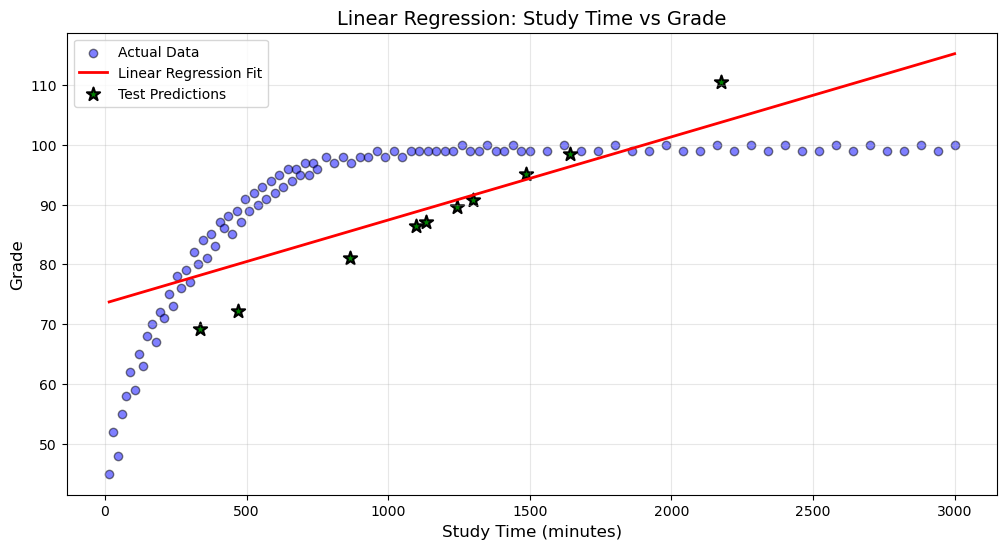


The red line shows our learned model: Grade = 11.503446 × Study_Time + 88.053837


In [80]:
# Generate predictions for the entire dataset
y_pred_all = predict(X, w_loaded, b_loaded)

# Create visualization
plt.figure(figsize=(12, 6))

# Plot original data points
plt.scatter(X, y, alpha=0.5, color='blue', label='Actual Data', edgecolors='k')

# Plot regression line
plt.plot(X, y_pred_all, color='red', linewidth=2, label='Linear Regression Fit')

# Plot test predictions
plt.scatter(test_study_times, test_predictions, color='green', 
            s=100, marker='*', label='Test Predictions', 
            edgecolors='black', linewidth=1.5)

plt.xlabel('Study Time (minutes)', fontsize=12)
plt.ylabel('Grade', fontsize=12)
plt.title('Linear Regression: Study Time vs Grade', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nThe red line shows our learned model: Grade = {w_loaded:.6f} × Study_Time + {b_loaded:.6f}")

In [81]:
# Calculate final performance metrics
final_mse = compute_mse(y, y_pred_all)
rmse = np.sqrt(final_mse)

# Calculate R-squared (coefficient of determination)
ss_res = np.sum((y - y_pred_all)**2)  # Residual sum of squares
ss_tot = np.sum((y - np.mean(y))**2)  # Total sum of squares
r_squared = 1 - (ss_res / ss_tot)

print("Model Performance Metrics:")
print("=" * 50)
print(f"Mean Squared Error (MSE): {final_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.4f}")
print("=" * 50)
print(f"\n📊 R² = {r_squared:.4f} means our model explains {r_squared*100:.2f}% of the variance in the data!")

Model Performance Metrics:
Mean Squared Error (MSE): 105.05
Root Mean Squared Error (RMSE): 10.25
R-squared (R²): 0.4384

📊 R² = 0.4384 means our model explains 43.84% of the variance in the data!


<a name='10'></a>
## 10 - Conclusion

Congratulations! 🎉 You've successfully implemented linear regression from scratch!

### What you've learned:

1. **Mathematical Foundation:**
   - Prediction formula: $\hat{y} = wx + b$
   - Mean Squared Error (MSE) loss function
   - Gradient computation using calculus
   - Gradient descent optimization

2. **Implementation Skills:**
   - Built all components from scratch using NumPy
   - Implemented forward pass (predictions)
   - Implemented backward pass (gradients)
   - Created a complete training loop

3. **Practical ML Workflow:**
   - Loaded and visualized data
   - Trained a model with gradient descent
   - Saved model weights for reuse
   - Loaded weights and made predictions
   - Evaluated model performance

### Key Insights:

- Linear regression finds the best straight line through the data
- Gradient descent iteratively improves the model by following the negative gradient
- The learning rate controls how quickly the model learns
- MSE measures how close predictions are to actual values
- Model weights can be saved and reused without retraining

### Next Steps:

- Try different learning rates and see how they affect training
- Experiment with different numbers of iterations
- Add data normalization to improve training
- Try polynomial regression for non-linear relationships
- Implement regularization to prevent overfitting

### Remember:

This is the foundation for understanding more complex models like neural networks! The concepts you learned here (forward pass, loss computation, gradients, optimization) are the same ones used in deep learning.

Keep practicing! 🚀

---

## Bonus: Mathematical Derivation

For those interested in the mathematics, here's how we derive the gradients:

### MSE Loss:
$$L = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$

### Gradient with respect to w:
$$\frac{\partial L}{\partial w} = \frac{\partial}{\partial w} \left[ \frac{1}{m} \sum_{i=1}^{m} (wx^{(i)} + b - y^{(i)})^2 \right]$$

Using the chain rule:
$$\frac{\partial L}{\partial w} = \frac{2}{m} \sum_{i=1}^{m} (wx^{(i)} + b - y^{(i)}) \cdot x^{(i)}$$

### Gradient with respect to b:
$$\frac{\partial L}{\partial b} = \frac{\partial}{\partial b} \left[ \frac{1}{m} \sum_{i=1}^{m} (wx^{(i)} + b - y^{(i)})^2 \right]$$

Using the chain rule:
$$\frac{\partial L}{\partial b} = \frac{2}{m} \sum_{i=1}^{m} (wx^{(i)} + b - y^{(i)})$$

These are the formulas we implemented in our `compute_gradients` function!